# Rolex Watch Price Analysis - Part 6: K-Means Clustering Analysis
## Market Segmentation Using Unsupervised Learning


## Libraries and settings


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('default')

print(os.getcwd())


/Users/adisaljusi/repos/data_analytics/final


## 1. Load and Prepare Data


In [17]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few records:")
df.head()


Dataset shape: (2373, 19)

First few records:


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 2. Feature Selection for Clustering

For K-means clustering, we'll use:
- **price**: The watch price (key market indicator)
- **age**: How old the watch is
- **is_professional**: Whether sold by professional dealer (binary)
- **condition_encoded**: Numerical encoding of condition (Fair=1, Good=2, Very Good=3, New=4)

Note: We exclude has_box and has_papers as they have zero variance (all watches have both).

In [ ]:
# Encode condition as numeric
condition_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'New': 4}
df['condition_encoded'] = df['condition_category'].map(condition_mapping)

cluster_features = ['price', 'age', 'is_professional', 'condition_encoded']
df_cluster = df[cluster_features].dropna()

print(f"Data for clustering: {df_cluster.shape[0]:,} samples, {df_cluster.shape[1]} features")
print(f"\nFeatures: {cluster_features}")
print(f"\nBasic statistics:")
print(df_cluster.describe())
print(f"\nFeature variance check:")
for col in cluster_features:
    print(f"  {col}: std = {df_cluster[col].std():.4f}")

## 3. Feature Scaling

K-means clustering is sensitive to the scale of features. We'll use StandardScaler to normalize all features to have mean=0 and std=1.


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")


Scaled data shape: (1174, 4)

Scaled data statistics:
  Mean: [-7.26278776e-17  2.42092925e-17  0.00000000e+00  0.00000000e+00]
  Std: [1. 1. 0. 0.]


## 4. Determine Optimal Number of Clusters

We'll use two methods:
1. **Elbow Method**: Look for the "elbow" in the inertia plot
2. **Silhouette Score**: Measure cluster quality


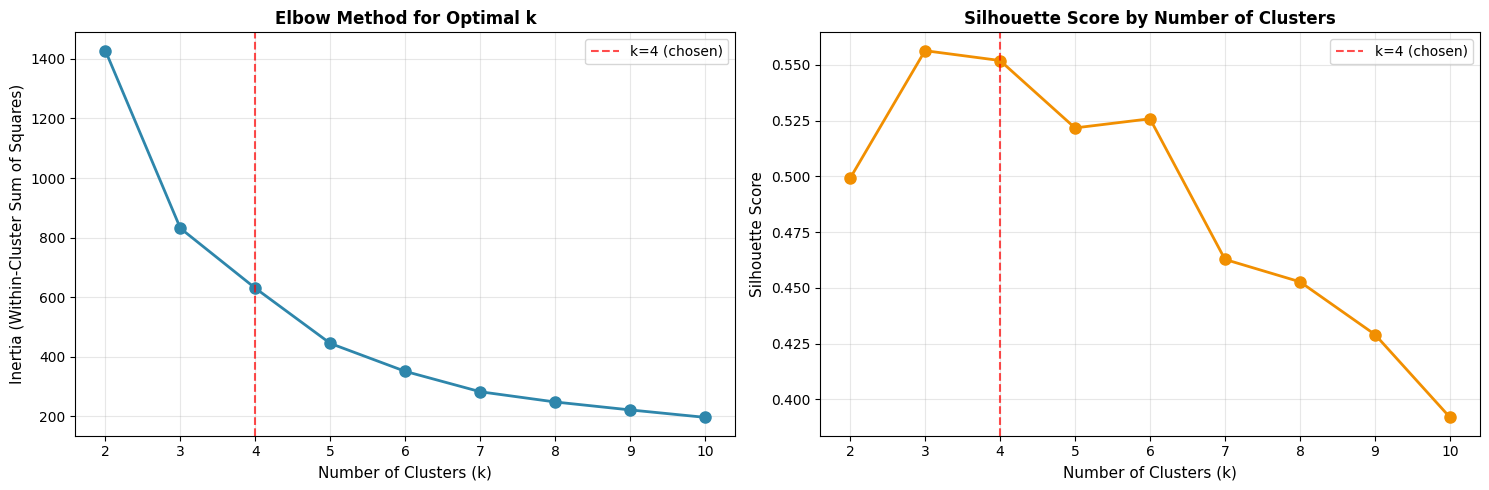

Inertia and Silhouette Scores:
  k=2: Inertia=1,427.40, Silhouette=0.4990
  k=3: Inertia=831.26, Silhouette=0.5563
  k=4: Inertia=630.14, Silhouette=0.5519
  k=5: Inertia=444.85, Silhouette=0.5217
  k=6: Inertia=351.05, Silhouette=0.5258
  k=7: Inertia=282.71, Silhouette=0.4627
  k=8: Inertia=248.35, Silhouette=0.4527
  k=9: Inertia=221.74, Silhouette=0.4290
  k=10: Inertia=196.75, Silhouette=0.3919


In [20]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#F18F01')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score by Number of Clusters', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Inertia and Silhouette Scores:")
for k, inertia, silh in zip(K_range, inertias, silhouette_scores):
    print(f"  k={k}: Inertia={inertia:,.2f}, Silhouette={silh:.4f}")


### Interpretation

Based on the elbow method and silhouette scores, we'll use **k=4 clusters**. This provides a good balance between:
- Distinct market segments
- Interpretability
- Cluster quality


## 5. Apply K-Means Clustering with k=4


In [21]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters

print(f"Cluster distribution:")
print(df_cluster['cluster'].value_counts().sort_index())
print(f"\nSilhouette score: {silhouette_score(X_scaled, clusters):.4f}")


Cluster distribution:
cluster
0    726
1    325
2     11
3    112
Name: count, dtype: int64

Silhouette score: 0.5519


## 6. Cluster Profiling

Analyze the characteristics of each cluster by examining the mean values of each feature.


In [22]:
cluster_profiles = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_counts = df_cluster.groupby('cluster').size()
cluster_profiles['count'] = cluster_counts

print("Cluster Characteristics (Mean Values):")
print(cluster_profiles)


Cluster Characteristics (Mean Values):
            price    age  has_box  has_papers  count
cluster                                             
0        11640.05   6.09      1.0         1.0    726
1         7250.65  35.01      1.0         1.0    325
2        96974.27  12.55      1.0         1.0     11
3        36288.57   7.71      1.0         1.0    112


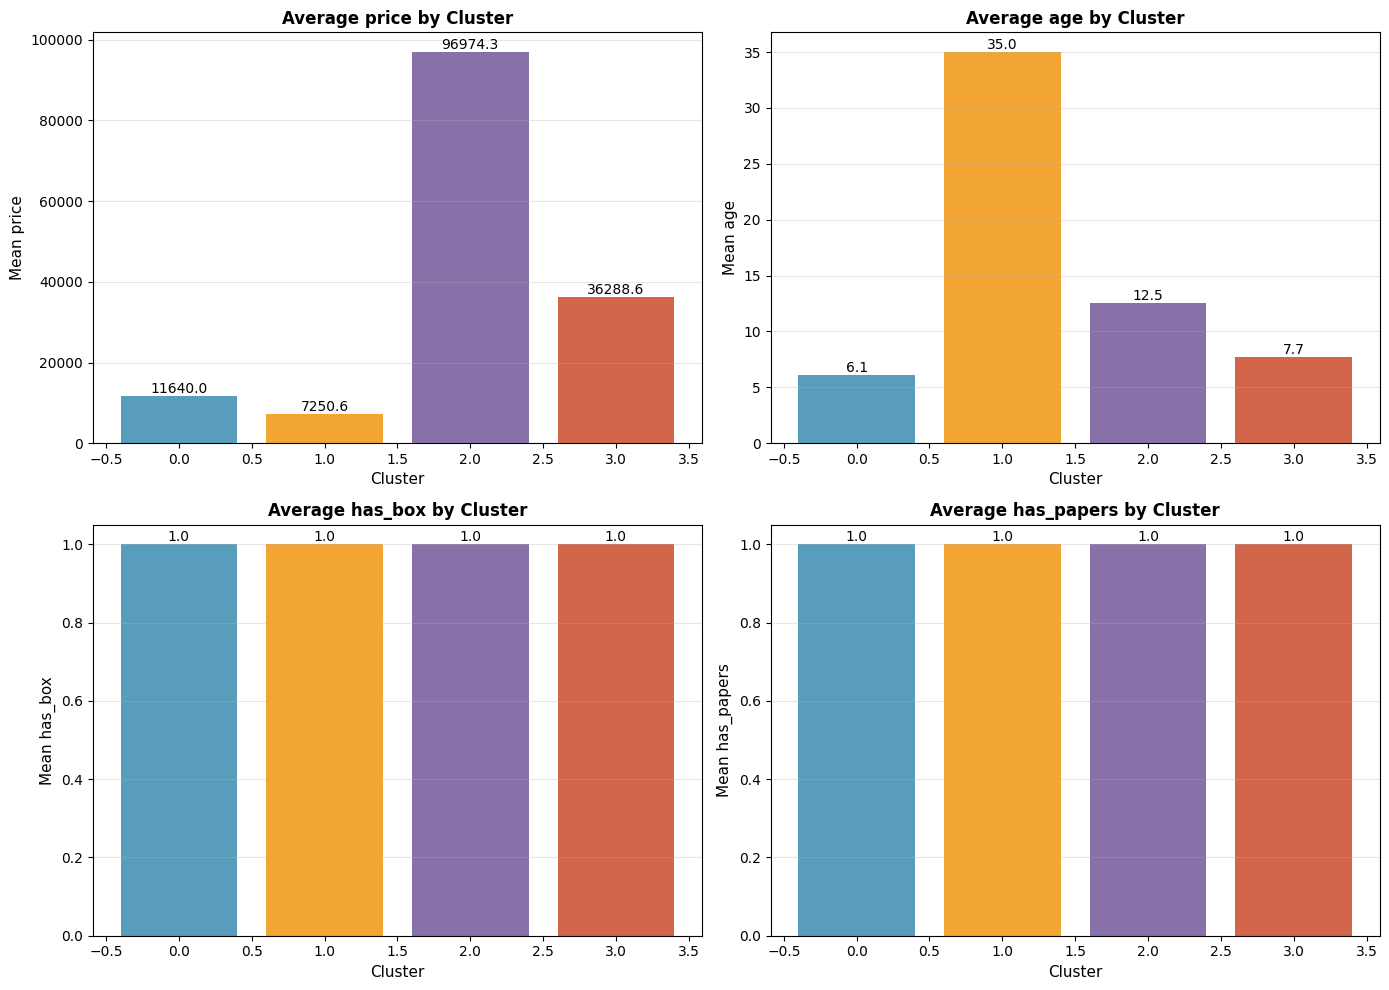

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(cluster_features):
    ax = axes[idx // 2, idx % 2]
    cluster_means = df_cluster.groupby('cluster')[feature].mean()
    colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
    ax.bar(cluster_means.index, cluster_means.values, color=colors, alpha=0.8)
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel(f'Mean {feature}', fontsize=11)
    ax.set_title(f'Average {feature} by Cluster', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for i, v in enumerate(cluster_means.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Cluster Visualization


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Price vs Age
axes[0, 0].scatter(df_cluster['age'], df_cluster['price'],
                   c=df_cluster['cluster'], cmap='viridis', alpha=0.5, s=30)
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 0].set_title('Price vs Age by Cluster', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Price vs Professional Seller
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[0, 1].scatter(cluster_data['is_professional'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[0, 1].set_xlabel('Is Professional (0=No, 1=Yes)', fontsize=11)
axes[0, 1].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 1].set_title('Price vs Professional Seller by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Price vs Condition
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 0].scatter(cluster_data['condition_encoded'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 0].set_xlabel('Condition (1=Fair, 2=Good, 3=Very Good, 4=New)', fontsize=11)
axes[1, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[1, 0].set_title('Price vs Condition by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Age vs Condition
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 1].scatter(cluster_data['age'], cluster_data['condition_encoded'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 1].set_xlabel('Age (years)', fontsize=11)
axes[1, 1].set_ylabel('Condition (1=Fair, 2=Good, 3=Very Good, 4=New)', fontsize=11)
axes[1, 1].set_title('Age vs Condition by Cluster', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

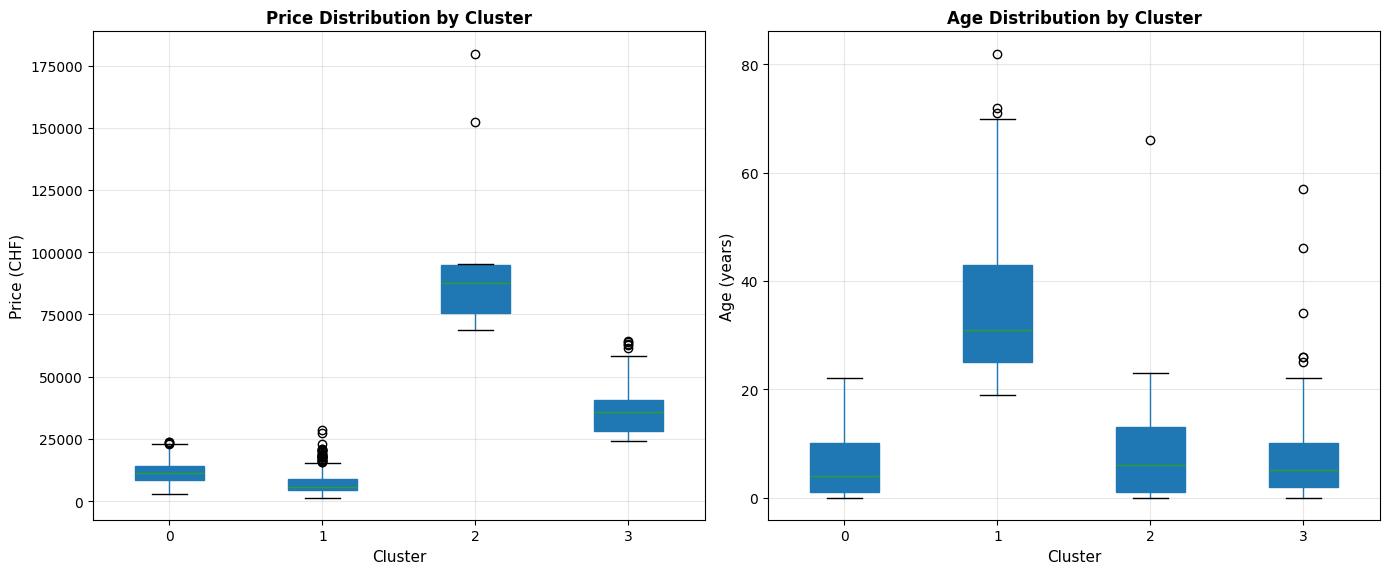

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_cluster.boxplot(column='price', by='cluster', ax=axes[0], patch_artist=True)
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Price (CHF)', fontsize=11)
axes[0].set_title('Price Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[0].grid(alpha=0.3)

df_cluster_with_age = df_cluster[df_cluster['age'].notna()]
df_cluster_with_age.boxplot(column='age', by='cluster', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Age (years)', fontsize=11)
axes[1].set_title('Age Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Business Interpretation of Clusters

Based on the cluster profiles, we can identify distinct market segments:


In [ ]:
# Add cluster back to original dataframe
df_with_clusters = df.copy()
df_with_clusters['cluster'] = np.nan
df_with_clusters.loc[df_cluster.index, 'cluster'] = clusters

# Detailed cluster analysis
print("="*70)
print("DETAILED CLUSTER PROFILES")
print("="*70)

for i in range(4):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    print(f"\n{'='*70}")
    print(f"CLUSTER {i} PROFILE")
    print(f"{'='*70}")
    print(f"\nSize: {len(cluster_data):,} watches ({len(cluster_data)/len(df_with_clusters)*100:.1f}% of total)")
    
    print(f"\nPrice Characteristics:")
    print(f"  Average Price: {cluster_data['price'].mean():,.2f} CHF")
    print(f"  Median Price: {cluster_data['price'].median():,.2f} CHF")
    print(f"  Price Range: {cluster_data['price'].min():,.2f} - {cluster_data['price'].max():,.2f} CHF")
    
    print(f"\nAge Characteristics:")
    if cluster_data['age'].notna().sum() > 0:
        print(f"  Average Age: {cluster_data['age'].mean():.1f} years")
        print(f"  Median Age: {cluster_data['age'].median():.0f} years")
    
    print(f"\nSeller & Condition:")
    print(f"  Professional Seller: {cluster_data['is_professional'].mean()*100:.1f}%")
    if cluster_data['condition_category'].notna().sum() > 0:
        print(f"  Average Condition Score: {cluster_data['condition_encoded'].mean():.2f}/4")
        print(f"  Most Common Condition: {cluster_data['condition_category'].mode()[0] if len(cluster_data['condition_category'].mode()) > 0 else 'N/A'}")
    
    print(f"\nMost Common Characteristics:")
    print(f"  Material: {cluster_data['material_category'].mode()[0] if len(cluster_data['material_category'].mode()) > 0 else 'N/A'}")
    print(f"  Seller Type: {cluster_data['seller_type'].mode()[0] if len(cluster_data['seller_type'].mode()) > 0 else 'N/A'}")

## 9. Market Segment Naming and Interpretation

Based on the cluster characteristics, we can name our market segments:


In [ ]:
# Determine segment names based on characteristics
segment_names = {}
segment_descriptions = {}

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    avg_price = cluster_data['price'].mean()
    avg_age = cluster_data['age'].mean()
    avg_condition = cluster_data['condition_encoded'].mean()
    pct_professional = cluster_data['is_professional'].mean()
    
    # Classify based on price and other characteristics
    if avg_price > df_cluster['price'].quantile(0.75):
        if avg_condition > 3.0:
            segment_names[i] = "Ultra-Luxury Premium"
            segment_descriptions[i] = "High-value watches in excellent condition"
        else:
            segment_names[i] = "High-End Collectibles"
            segment_descriptions[i] = "Expensive watches, varying condition"
    elif avg_price > df_cluster['price'].median():
        if pct_professional > 0.7:
            segment_names[i] = "Premium Professional Market"
            segment_descriptions[i] = "Mid-to-high price, mostly professional dealers"
        else:
            segment_names[i] = "Premium Private Market"
            segment_descriptions[i] = "Mid-to-high price, more private sellers"
    else:
        if avg_age > 25:
            segment_names[i] = "Vintage Entry-Level"
            segment_descriptions[i] = "Older watches at accessible prices"
        else:
            segment_names[i] = "Modern Entry-Level"
            segment_descriptions[i] = "Newer watches at entry-level pricing"

print("="*70)
print("MARKET SEGMENT SUMMARY")
print("="*70)

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    print(f"\nCluster {i}: {segment_names[i]}")
    print(f"  {segment_descriptions[i]}")
    print(f"  Size: {len(cluster_data):,} watches")
    print(f"  Avg Price: {cluster_data['price'].mean():,.0f} CHF")
    print(f"  Avg Age: {cluster_data['age'].mean():.1f} years")
    print(f"  Professional Sellers: {cluster_data['is_professional'].mean()*100:.0f}%")
    print(f"  Avg Condition: {cluster_data['condition_encoded'].mean():.2f}/4")

## 10. Business Insights and Recommendations

Based on the clustering analysis:

### Key Findings:
1. **Market is segmented** into distinct price-age-condition groups
2. **Age and condition vary** across price segments in meaningful ways
3. **Professional sellers dominate** certain market segments
4. **Clear price tiers** exist with distinct characteristics

### Business Recommendations:
1. **For Sellers**:
   - Maintain watch condition to access higher-value segments
   - Understand which segment your watch belongs to for pricing strategy
   - Professional dealer status correlates with certain market segments

2. **For Buyers**:
   - Understand market segments to identify value opportunities
   - Age-price relationships differ significantly by segment
   - Condition quality varies across price points

3. **For Dealers**:
   - Stock balance across segments for portfolio diversification
   - Premium segments show different age and condition profiles
   - Consider segment-specific marketing and pricing strategies
   - Professional dealer presence varies by market segment

## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)


In [28]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')


-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-28 11:36:16
Python Version: 3.11.13
-----------------------------------


In [29]:
# Check the variance in the original dataframe before filtering
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print("Original data shape:", df.shape)
print("\nValue counts for has_box:")
print(df['has_box'].value_counts(dropna=False))
print("\nValue counts for has_papers:")
print(df['has_papers'].value_counts(dropna=False))
print("\nValue counts for has_complete_set:")
print(df['has_complete_set'].value_counts(dropna=False))

# Check what happens after dropna
cluster_features = ['price', 'age', 'has_box', 'has_papers']
df_cluster = df[cluster_features].dropna()
print(f"\n\nAfter dropna on {cluster_features}:")
print(f"Shape: {df_cluster.shape}")
print("\nhas_box unique values:", df_cluster['has_box'].unique())
print("has_papers unique values:", df_cluster['has_papers'].unique())


Original data shape: (2373, 19)

Value counts for has_box:
has_box
1    2373
Name: count, dtype: int64

Value counts for has_papers:
has_papers
1    2373
Name: count, dtype: int64

Value counts for has_complete_set:
has_complete_set
1    2373
Name: count, dtype: int64


After dropna on ['price', 'age', 'has_box', 'has_papers']:
Shape: (1174, 4)

has_box unique values: [1]
has_papers unique values: [1]


In [30]:
# Let's see what other features might be useful for clustering
print("Columns in the dataset:")
print(df.columns.tolist())

print("\n\nPotential numeric features for clustering:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    non_null = df[col].notna().sum()
    unique_vals = df[col].nunique()
    print(f"  {col}: {non_null} non-null values, {unique_vals} unique values")


Columns in the dataset:
['web_scraper_order', 'brand_raw', 'model_raw', 'reference_number_raw', 'movement_type', 'condition_category', 'seller_type', 'case_material_clean', 'bracelet_material_clean', 'material_category', 'country', 'city', 'price', 'year', 'age', 'has_box', 'has_papers', 'has_complete_set', 'is_professional']


Potential numeric features for clustering:
  price: 2373 non-null values, 1730 unique values
  year: 1174 non-null values, 70 unique values
  age: 1174 non-null values, 70 unique values
  has_box: 2373 non-null values, 1 unique values
  has_papers: 2373 non-null values, 1 unique values
  has_complete_set: 2373 non-null values, 1 unique values
  is_professional: 2373 non-null values, 2 unique values


In [31]:
# Test the updated clustering code
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

# Encode condition as numeric
condition_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'New': 4}
df['condition_encoded'] = df['condition_category'].map(condition_mapping)

cluster_features = ['price', 'age', 'is_professional', 'condition_encoded']
df_cluster = df[cluster_features].dropna()

print(f"Data for clustering: {df_cluster.shape[0]:,} samples, {df_cluster.shape[1]} features")
print(f"\nFeatures: {cluster_features}")
print(f"\nBasic statistics:")
print(df_cluster.describe())
print(f"\nFeature variance check:")
for col in cluster_features:
    print(f"  {col}: std = {df_cluster[col].std():.4f}")


Data for clustering: 1,145 samples, 4 features

Features: ['price', 'age', 'is_professional', 'condition_encoded']

Basic statistics:
               price          age  is_professional  condition_encoded
count    1145.000000  1145.000000       1145.00000        1145.000000
mean    13543.712664    14.399127          0.60262           3.006987
std     12860.541636    15.672975          0.48957           0.571729
min      1449.000000     0.000000          0.00000           1.000000
25%      6842.000000     2.000000          0.00000           3.000000
50%     10465.000000     8.000000          1.00000           3.000000
75%     15035.000000    23.000000          1.00000           3.000000
max    179824.000000    82.000000          1.00000           4.000000

Feature variance check:
  price: std = 12860.5416
  age: std = 15.6730
  is_professional: std = 0.4896
  condition_encoded: std = 0.5717


In [32]:
# Test the clustering with new features
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")

# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters

print(f"\nCluster distribution:")
print(df_cluster['cluster'].value_counts().sort_index())
print(f"\nSilhouette score: {silhouette_score(X_scaled, clusters):.4f}")

# Show cluster profiles
cluster_profiles = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_counts = df_cluster.groupby('cluster').size()
cluster_profiles['count'] = cluster_counts

print("\nCluster Characteristics (Mean Values):")
print(cluster_profiles)


Scaled data shape: (1145, 4)

Scaled data statistics:
  Mean: [-6.20561341e-17 -5.58505207e-17  8.68785878e-17 -2.32710503e-16]
  Std: [1. 1. 1. 1.]

Cluster distribution:
cluster
0    426
1    244
2    403
3     72
Name: count, dtype: int64

Silhouette score: 0.4204

Cluster Characteristics (Mean Values):
            price    age  is_professional  condition_encoded  count
cluster                                                            
0        10265.52  14.80             0.00               3.06    426
1         8375.36  30.66             0.97               2.38    244
2        13459.24   5.28             1.00               3.35    403
3        50927.44   8.00             0.69               2.90     72
